In [2]:
import pandas as pd
import numpy as np
from ipdb import set_trace as bp
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

FONT_SIZE = 12
BRACKET_COLOR = '#666666'
PLOT_TYPE = 'box'   # 'box' or 'violin'
USE_BEESWARM = False  # overlay beeswarm on box or violin when True

def get_significance_stars(pval):
    if pval < 0.001:
        return '***'
    elif pval < 0.01:
        return '**'
    elif pval < 0.05:
        return '*'
    else:
        return 'ns'

df = pd.read_csv('../data/inference_v6emb_3920_all.csv')
df['date'] = pd.to_datetime(df['date'])
# Convert logits to probabilities
df['pred'] = 1 / (1 + np.exp(-df['pred']))

start1 = pd.Timestamp('2020-12-15')
start2 = pd.Timestamp('2020-12-22')
start3 = pd.Timestamp('2021-01-28')
start = start1 - pd.Timedelta(days=23)
end = start3 + pd.Timedelta(days=21)




/var/folders/xy/rzr08p1j3sl01n53xryhfsx80000gn/T/ipykernel_63349/1835241740.py:23: DtypeWarning: Columns (144) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../data/inference_v6emb_3920_all.csv')


In [3]:
def get_sleep_time(filename):
    data = np.load('../data/1007/1007/'+filename.split('/')[-1])['data']
    return (data > 0).sum() / 2
def get_rem_time(filename):
    data = np.load('../data/1007/1007/'+filename.split('/')[-1])['data']
    return (data == 4).sum() / 2
def get_waso(filename):
    data = np.load('../data/1007/1007/'+filename.split('/')[-1])['data']
    sleep_time = list(data > 0).index(True)
    wake_time = len(data) - list(data[::-1] > 0).index(True)
    return (data[sleep_time:wake_time] == 0).sum()

# def get_bad_signal_time(filename):
#     pid = filename.split('_')[0]
#     data = np.load(f'/data/netmit/sleep_lab/rf/snr/{pid}/{filename}')
#     start_idx = start_stop_dict[filename][0]
#     end_idx = start_stop_dict[filename][1]
#     return (data[start_idx:end_idx] < 0.5).sum() / (5 * 60)
    

In [59]:


df1007 = df[df['pid'] == '1007'].copy() 
df1007['sleep_time'] = df1007['filename'].apply(lambda x: get_sleep_time(x))
df1007['rem_time'] = df1007['filename'].apply(lambda x: get_rem_time(x))
df1007['waso'] = df1007['filename'].apply(lambda x: get_waso(x))
df1007['filename'] = df1007['filename'].apply(lambda x: x.split('/')[-1])
bad_sig = pd.read_csv('../data/bad_signal_time_1007.csv')
print(df1007.shape)
df1007 = pd.merge(df1007, bad_sig, on='filename', how='inner')
print(df1007.shape)



(286, 148)
(286, 150)


In [70]:
section0 = df1007[(df1007['pid'] == '1007') & (df1007['date'] > start) &  (df1007['date'] <= start1)]  # Control
section1 = df1007[(df1007['pid'] == '1007') & (df1007['date'] > start1) & (df1007['date'] <= start2)]   # 37.5mg
section2 = df1007[(df1007['pid'] == '1007') & (df1007['date'] > start2) & (df1007['date'] <= start3)]  # 75mg
section3 = df1007[(df1007['pid'] == '1007') & (df1007['date'] > start3) & (df1007['date'] < end)]     # 150mg

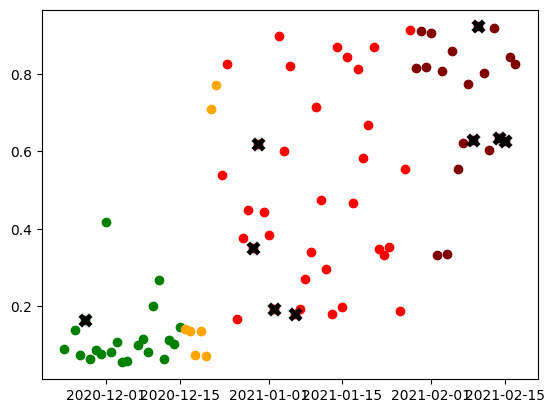

In [71]:
plt.scatter(section0['date'], section0['pred'], color='green')
plt.scatter(section1['date'], section1['pred'], color='orange')
plt.scatter(section2['date'], section2['pred'], color='red')
plt.scatter(section3['date'], section3['pred'], color='maroon')
## put an X over the dots where bad_signal_time > 50
threshold = 70
plt.scatter(section0[section0['bad_signal_time'] > threshold]['date'], section0[section0['bad_signal_time'] > threshold]['pred'], color='black', marker='X', lw=0.1,s=100)
plt.scatter(section1[section1['bad_signal_time'] > threshold]['date'], section1[section1['bad_signal_time'] > threshold]['pred'], color='black', marker='X', lw=0.1,s=100)
plt.scatter(section2[section2['bad_signal_time'] > threshold]['date'], section2[section2['bad_signal_time'] > threshold]['pred'], color='black', marker='X', lw=0.1,s=100)
plt.scatter(section3[section3['bad_signal_time'] > threshold]['date'], section3[section3['bad_signal_time'] > threshold]['pred'], color='black', marker='X', lw=0.1,s=100)



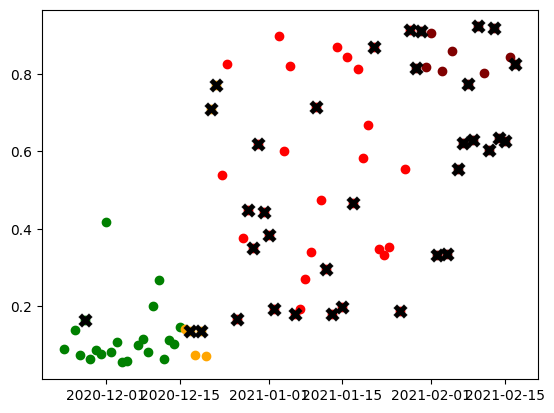

In [63]:
plt.scatter(section0['date'], section0['pred'], color='green')
plt.scatter(section1['date'], section1['pred'], color='orange')
plt.scatter(section2['date'], section2['pred'], color='red')
plt.scatter(section3['date'], section3['pred'], color='maroon')
## put an X over the dots where bad_signal_time > 50
threshold = 50
plt.scatter(section0[section0['bad_signal_time'] > threshold]['date'], section0[section0['bad_signal_time'] > threshold]['pred'], color='black', marker='X', lw=0.1,s=100)
plt.scatter(section1[section1['bad_signal_time'] > threshold]['date'], section1[section1['bad_signal_time'] > threshold]['pred'], color='black', marker='X', lw=0.1,s=100)
plt.scatter(section2[section2['bad_signal_time'] > threshold]['date'], section2[section2['bad_signal_time'] > threshold]['pred'], color='black', marker='X', lw=0.1,s=100)
plt.scatter(section3[section3['bad_signal_time'] > threshold]['date'], section3[section3['bad_signal_time'] > threshold]['pred'], color='black', marker='X', lw=0.1,s=100)



Text(0.5, 1.0, 'Patient Loading Venlafaxine')

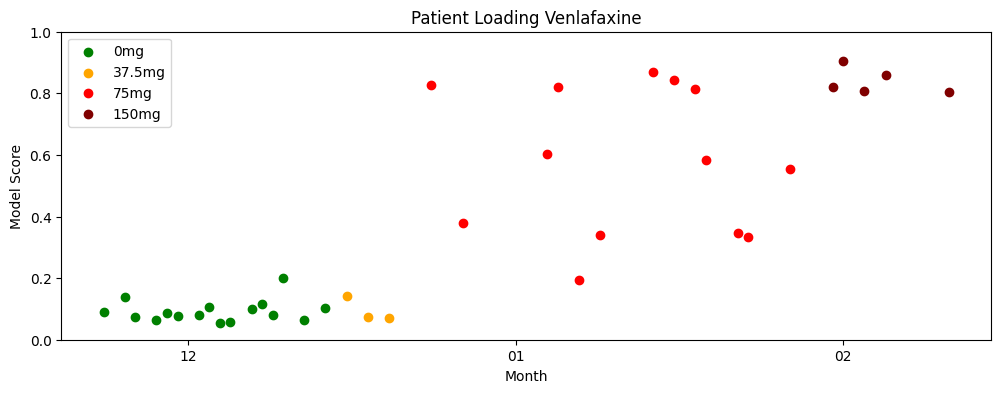

In [64]:
import matplotlib.dates as mdates
threshold = 30
fig, ax = plt.subplots(figsize=(12, 4))

ax.scatter(section0[section0['bad_signal_time'] < threshold]['date'], section0[section0['bad_signal_time'] < threshold]['pred'], color='green', label='0mg')
ax.scatter(section1[section1['bad_signal_time'] < threshold]['date'], section1[section1['bad_signal_time'] < threshold]['pred'], color='orange', label='37.5mg')
ax.scatter(section2[section2['bad_signal_time'] < threshold]['date'], section2[section2['bad_signal_time'] < threshold]['pred'], color='red', label='75mg')
ax.scatter(section3[section3['bad_signal_time'] < threshold]['date'], section3[section3['bad_signal_time'] < threshold]['pred'], color='maroon', label='150mg')
# ax.xaxis.set_minor_locator(mdates.WeekdayLocator(byweekday=0))  # every Monday

# 2. Set major ticks at the start of each month (for labels)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m"))  # e.g. "Jan 2024"
ax.set_xlabel('Month')
ax.set_ylabel('Model Score')
ax.set_ylim(0, 1)
ax.legend()
ax.set_title('Patient Loading Venlafaxine')
## put an X over the dots where bad_signal_time > 50


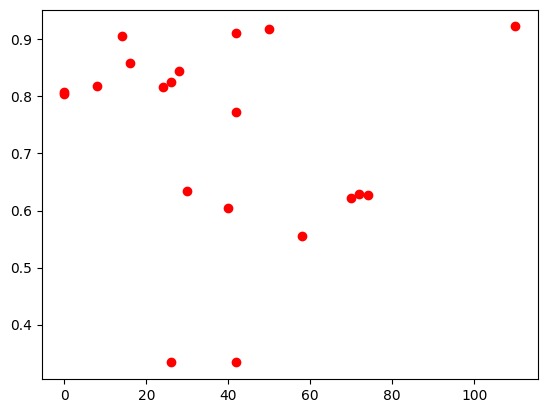

In [44]:
plt.scatter(section3['bad_signal_time'], section3['pred'], color='red')

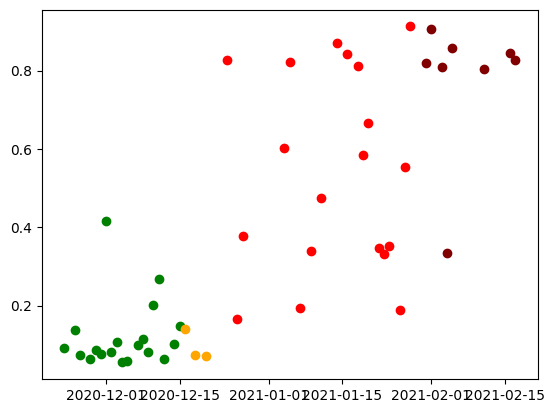

In [74]:
threshold = 30
plt.scatter(section0[section0['bad_signal_time'] < threshold]['date'], section0[section0['bad_signal_time'] < threshold]['pred'], color='green')
plt.scatter(section1[section1['bad_signal_time'] < threshold]['date'], section1[section1['bad_signal_time'] < threshold]['pred'], color='orange')
plt.scatter(section2[section2['bad_signal_time'] < threshold]['date'], section2[section2['bad_signal_time'] < threshold]['pred'], color='red')
plt.scatter(section3[section3['bad_signal_time'] < threshold]['date'], section3[section3['bad_signal_time'] < threshold]['pred'], color='maroon')
## put an X over the dots where bad_signal_time > 50


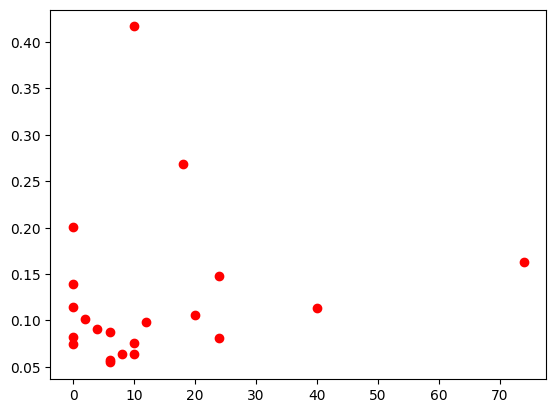

In [52]:
plt.scatter(section0['bad_signal_time'], section0['pred'], color='red')

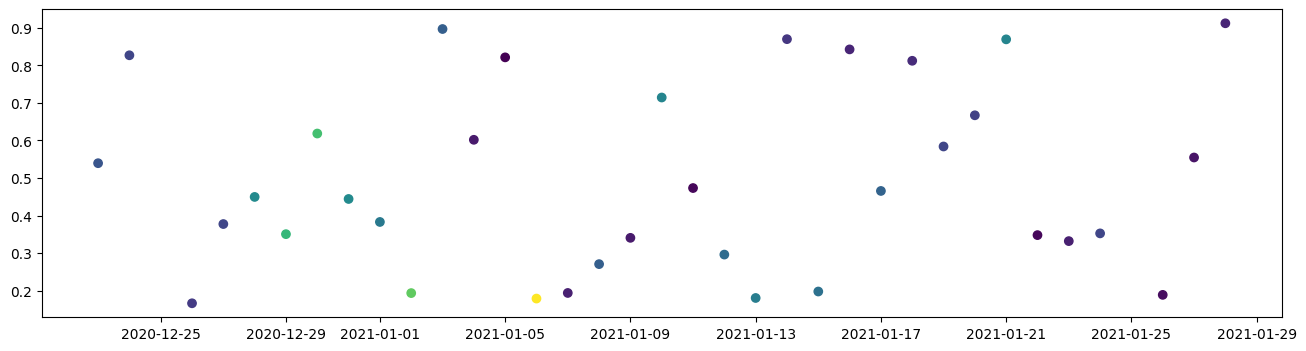

In [47]:
plt.figure(figsize=(16,4))
plt.scatter(section2['date'], section2['pred'],c=section2['bad_signal_time'], cmap='viridis')

In [69]:
df1007['bad_signal_time'] = df1007['bad_signal_time_binary']

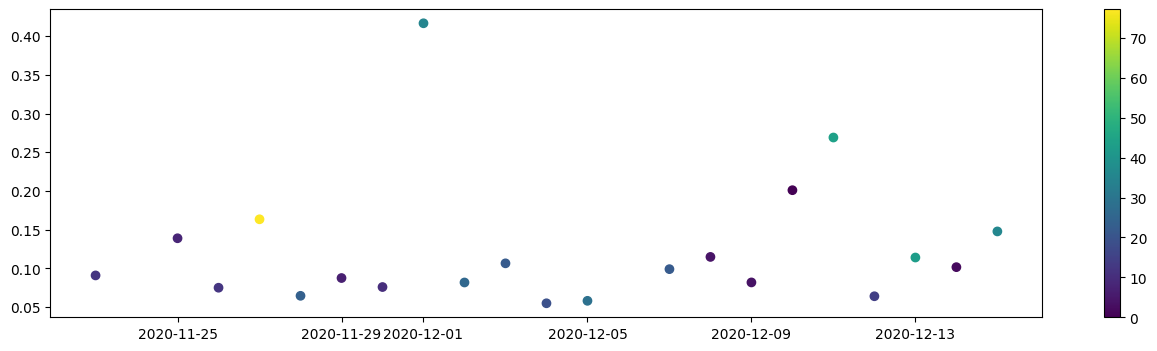

In [130]:
plt.figure(figsize=(16,4))
plt.scatter(section0['date'],section0['pred'], c=section0['bad_signal_time'], cmap='viridis')
plt.colorbar()

In [98]:
def auc_with_ci(labels, preds, n_bootstrap=1000, ci=0.95):
    # Convert to numpy arrays to avoid pandas index issues
    labels = np.array(labels)
    preds = np.array(preds)
    
    auc = roc_auc_score(labels, preds)
    
    aucs = []
    rng = np.random.default_rng(seed=42)
    n = len(labels)
    
    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, size=n)
        if len(np.unique(labels[idx])) < 2:
            continue
        aucs.append(roc_auc_score(labels[idx], preds[idx]))
    
    alpha = (1 - ci) / 2
    lower = np.percentile(aucs, 100 * alpha)
    upper = np.percentile(aucs, 100 * (1 - alpha))
    
    return auc, lower, upper

def fpr_with_ci(labels, preds, threshold=0.5, n_bootstrap=1000, ci=0.95):
    """False Positive Rate = FP / (FP + TN)"""
    labels = np.array(labels)
    preds = np.array(preds)
    
    binary_preds = (preds >= threshold).astype(int)
    tn = ((binary_preds == 0) & (labels == 0)).sum()
    fp = ((binary_preds == 1) & (labels == 0)).sum()
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0

    fprs = []
    rng = np.random.default_rng(seed=42)
    n = len(labels)

    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, size=n)
        if len(np.unique(labels[idx])) < 2:
            continue
        bp = (preds[idx] >= threshold).astype(int)
        tn_ = ((bp == 0) & (labels[idx] == 0)).sum()
        fp_ = ((bp == 1) & (labels[idx] == 0)).sum()
        fprs.append(fp_ / (fp_ + tn_) if (fp_ + tn_) > 0 else 0.0)

    alpha = (1 - ci) / 2
    lower = np.percentile(fprs, 100 * alpha)
    upper = np.percentile(fprs, 100 * (1 - alpha))

    return fpr, lower, upper


def fnr_with_ci(labels, preds, threshold=0.5, n_bootstrap=1000, ci=0.95):
    """False Negative Rate = FN / (FN + TP)"""
    labels = np.array(labels)
    preds = np.array(preds)

    binary_preds = (preds >= threshold).astype(int)
    tp = ((binary_preds == 1) & (labels == 1)).sum()
    fn = ((binary_preds == 0) & (labels == 1)).sum()
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0.0

    fnrs = []
    rng = np.random.default_rng(seed=42)
    n = len(labels)

    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, size=n)
        if len(np.unique(labels[idx])) < 2:
            continue
        bp = (preds[idx] >= threshold).astype(int)
        tp_ = ((bp == 1) & (labels[idx] == 1)).sum()
        fn_ = ((bp == 0) & (labels[idx] == 1)).sum()
        fnrs.append(fn_ / (fn_ + tp_) if (fn_ + tp_) > 0 else 0.0)

    alpha = (1 - ci) / 2
    lower = np.percentile(fnrs, 100 * alpha)
    upper = np.percentile(fnrs, 100 * (1 - alpha))

    return fnr, lower, upper

In [125]:
from sklearn.metrics import roc_auc_score
rf = df[df['dataset'] == 'rf'].copy()
rf['filename'] = rf['filename'].apply(lambda x: x.split('/')[-1])
bad_sig = pd.read_csv('../data/bad_signal_time.csv')
rf = pd.merge(rf, bad_sig, on='filename', how='inner')

print(rf.shape, rf['bad_signal_time'].max())
## quantile into 10 thresholds
thresholds = [0, 1, 10, 30, 60, 120, 240]
outputs = [] 
for i in range(1, len(thresholds)):
    subset = rf[(rf['bad_signal_time'] < thresholds[i]) & (rf['bad_signal_time'] >= thresholds[i-1])]
    auc , lower, upper = auc_with_ci(subset['label'], subset['pred'])
    print(f'AUC for threshold {thresholds[i-1]} to {thresholds[i]}: {auc}, N={len(subset)}, Percent Positive={len(subset[subset["label"] == 1])/len(subset)}')
    outputs.append([thresholds[i-1], thresholds[i], auc, lower, upper, len(subset)])



(33084, 146) 240.0
AUC for threshold 0 to 1: 0.8590468723519433, N=8228, Percent Positive=0.23456490034030142
AUC for threshold 1 to 10: 0.9032867659765185, N=7172, Percent Positive=0.21319018404907975
AUC for threshold 10 to 30: 0.9039777247757473, N=8556, Percent Positive=0.2552594670406732
AUC for threshold 30 to 60: 0.8393464506473911, N=4668, Percent Positive=0.33354755784061696
AUC for threshold 60 to 120: 0.8319140493369153, N=3597, Percent Positive=0.4323046983597442
AUC for threshold 120 to 240: 0.8587693171026505, N=861, Percent Positive=0.5017421602787456


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


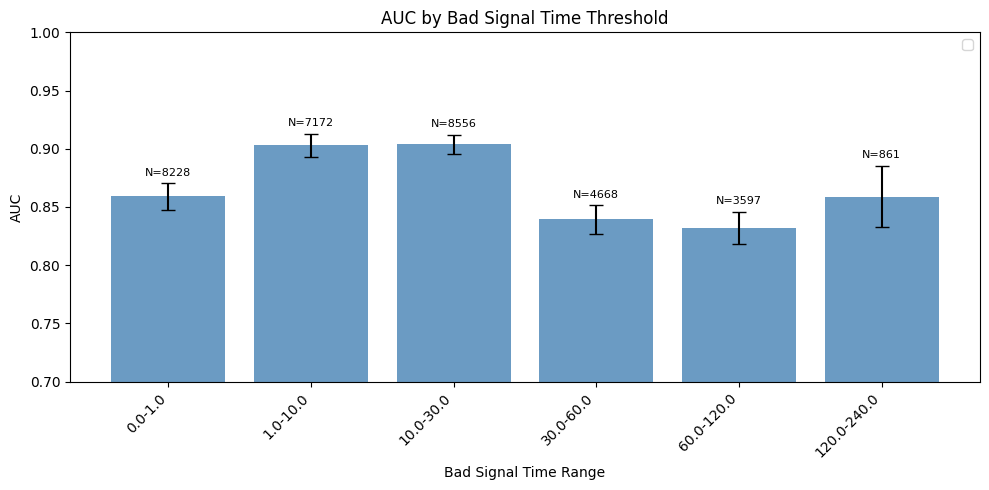

In [126]:
df_out = pd.DataFrame(outputs, columns=['lower_thresh', 'upper_thresh', 'auc', 'ci_lower', 'ci_upper', 'n'])

# Use midpoint or label for x-axis
df_out['label'] = df_out.apply(lambda r: f"{r['lower_thresh']}-{r['upper_thresh']}", axis=1)

fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(df_out))
yerr = [df_out['auc'] - df_out['ci_lower'], df_out['ci_upper'] - df_out['auc']]

ax.bar(x, df_out['auc'], color='steelblue', alpha=0.8,
       yerr=yerr, capsize=5, error_kw=dict(ecolor='black', lw=1.5))
for i, row in df_out.iterrows():
    ax.text(i, row['auc'] + (df_out['ci_upper'] - df_out['auc']).iloc[i] + 0.005,
            f"N={row['n']}", ha='center', va='bottom', fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(df_out['label'], rotation=45, ha='right')
ax.set_xlabel('Bad Signal Time Range')
ax.set_ylabel('AUC')
ax.set_title('AUC by Bad Signal Time Threshold')
ax.set_ylim(0.7, 1)
ax.axhline(0.5, color='red', linestyle='--', linewidth=1)
ax.legend()

plt.tight_layout()
plt.show()

In [133]:
from sklearn.metrics import roc_auc_score
rf = df[df['dataset'] == 'rf'].copy()
rf['filename'] = rf['filename'].apply(lambda x: x.split('/')[-1])
bad_sig = pd.read_csv('../data/bad_signal_time.csv')
rf = pd.merge(rf, bad_sig, on='filename', how='inner')

decision_threshold = 0.25

print(rf.shape, rf['bad_signal_time'].max())
## quantile into 10 thresholds
thresholds = [0, 10, 30, 60, 240]
fpr_outputs     = [] 
fnr_outputs     = [] 
for i in range(1, len(thresholds)):

    subset = rf[(rf['bad_signal_time'] < thresholds[i]) & (rf['bad_signal_time'] >= thresholds[i-1])]
    fpr, lower, upper = fpr_with_ci(subset['label'], subset['pred'], decision_threshold)
    fpr_outputs.append([thresholds[i-1], thresholds[i], fpr, lower, upper, len(subset)])
    fnr, lower, upper = fnr_with_ci(subset['label'], subset['pred'], decision_threshold)
    fnr_outputs.append([thresholds[i-1], thresholds[i], fnr, lower, upper, len(subset)])



(33084, 146) 240.0


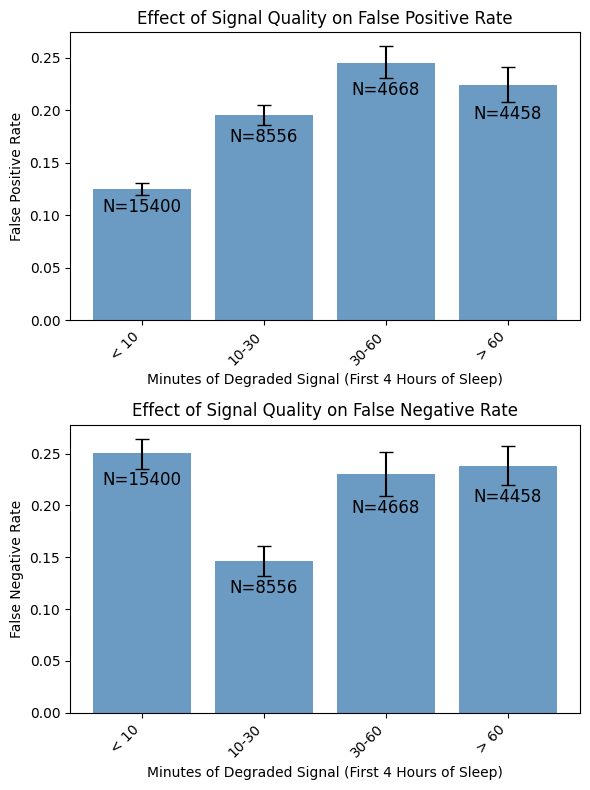

In [ ]:
df_fpr = pd.DataFrame(fpr_outputs, columns=['lower_thresh', 'upper_thresh', 'fpr', 'ci_lower', 'ci_upper', 'n'])
df_fnr = pd.DataFrame(fnr_outputs, columns=['lower_thresh', 'upper_thresh', 'fnr', 'ci_lower', 'ci_upper', 'n'])

# Use midpoint or label for x-axis
df_fpr['label'] = df_fpr.apply(lambda r: f"{r['lower_thresh']}-{r['upper_thresh']}", axis=1)
df_fnr['label'] = df_fnr.apply(lambda r: f"{r['lower_thresh']}-{r['upper_thresh']}", axis=1)

xlabels = [f"{r['lower_thresh']}-{r['upper_thresh']}" for i, r in df_fpr.iterrows()]
xlabels[0] = '< 10'
xlabels[-1] = '> 60'

fig, ax = plt.subplots(2, figsize=(6, 8))

x = np.arange(len(df_fpr))
yerr = [df_fpr['fpr'] - df_fpr['ci_lower'], df_fpr['ci_upper'] - df_fpr['fpr']]

ax[0].bar(x, df_fpr['fpr'], color='steelblue', alpha=0.8,
       yerr=[df_fpr['fpr'] - df_fpr['ci_lower'], df_fpr['ci_upper'] - df_fpr['fpr']], capsize=5, error_kw=dict(ecolor='black', lw=1.5))
ax[1].bar(x, df_fnr['fnr'], color='steelblue', alpha=0.8,
       yerr=[df_fnr['fnr'] - df_fnr['ci_lower'], df_fnr['ci_upper'] - df_fnr['fnr']], capsize=5, error_kw=dict(ecolor='black', lw=1.5))
for i, row in df_fpr.iterrows():
    ax[0].text(i, row['fpr'] - (df_fpr['fpr'] - df_fpr['ci_lower']).iloc[i] - 0.02,
            f"N={row['n']}", ha='center', va='bottom', fontsize=10)
for i, row in df_fnr.iterrows():
    ax[1].text(i, row['fnr'] - (df_fnr['fnr'] - df_fnr['ci_lower']).iloc[i] - 0.02,
            f"N={row['n']}", ha='center', va='bottom', fontsize=10)
ax[0].set_xticks(x)
ax[0].set_xticklabels(xlabels, rotation=45, ha='right')
ax[1].set_xticks(x)
ax[1].set_xticklabels(xlabels, rotation=45, ha='right')
ax[0].set_title('Effect of Signal Quality on False Positive Rate')
ax[0].set_xlabel('Minutes of Degraded Signal (First 4 Hours of Sleep)')
ax[0].set_ylabel('False Positive Rate')
ax[1].set_title('Effect of Signal Quality on False Negative Rate')
ax[1].set_xlabel('Minutes of Degraded Signal (First 4 Hours of Sleep)')
ax[1].set_ylabel('False Negative Rate')

plt.tight_layout()
plt.show()